In [29]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:

#Célula 1: Importação de Bibliotecas e Configurações

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, 
                             confusion_matrix, precision_recall_curve)

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")
np.random.seed(42)

In [ ]:

#Célula 2: Geração da Base de Dados Sintética

def generate_credit_data(n_samples=5000):
    data = {
        'idade': np.random.randint(18, 75, n_samples),
        'renda_mensal': np.random.gamma(shape=2, scale=2500, size=n_samples),
        'tempo_emprego_anos': np.random.exponential(scale=5, size=n_samples),
        'utilizacao_limite': np.random.beta(a=2, b=5, size=n_samples),
        'atrasos_90d': np.random.poisson(lam=0.2, size=n_samples),
        'num_dividas': np.random.randint(0, 10, n_samples),
        'historico_credito_anos': np.random.uniform(1, 30, n_samples)
    }
    df = pd.DataFrame(data)
    
    # Logit para definir a probabilidade de Default (PD)
    logit = (
        -0.05 * df['idade'] 
        - 0.0004 * df['renda_mensal'] 
        - 0.3 * df['tempo_emprego_anos'] 
        + 5.5 * df['utilizacao_limite'] 
        + 2.0 * df['atrasos_90d']
        + 0.3 * df['num_dividas']
        - 0.1 * df['historico_credito_anos']
    )
    prob = 1 / (1 + np.exp(-logit + 2.5))
    df['default'] = (np.random.rand(n_samples) < prob).astype(int)
    return df

df = generate_credit_data()
print(f"Distribuição das classes:\n{df['default'].value_counts(normalize=True)}")
df.head()

Distribuição das classes:
default
0    0.9826
1    0.0174
Name: proportion, dtype: float64


,idade,renda_mensal,tempo_emprego_anos,utilizacao_limite,atrasos_90d,num_dividas,historico_credito_anos,default
0,56,6498.571181,11.224158,0.597765,4,7,7.728075,1
1,69,3532.267709,3.432088,0.388317,0,7,10.902820,0
2,46,2300.548777,3.929097,0.582060,0,3,10.053938,0
3,32,1555.608189,15.674756,0.269988,1,1,25.896886,0
4,60,3689.652944,10.889745,0.114680,0,3,2.379618,0


In [ ]:

#Célula 3: Pré-processamento e Divisão de Dados

X = df.drop('default', axis=1)
y = df['default']

# Split estratificado para manter a proporção de inadimplentes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 3500 amostras | Teste: 1500 amostras


In [33]:
# Célula 4: Treinamento do Modelo (Random Forest)

# class_weight='balanced' é fundamental para lidar com o desbalanceamento
model = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)
y_proba = model.predict_proba(X_test_scaled)[:, 1]




In [36]:
#Célula 5: Avaliação de Performance e Threshold Tuning

# Cálculo das métricas de separabilidade
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
ks = np.max(tpr - fpr)
gini = 2 * auc - 1

# Otimização do Threshold via Youden's J Statistic
optimal_idx = np.argmax(tpr - fpr) # Subtrai a taxa de alarmes falsos (fpr) da taxa de acertos (tpr) para cada threshold testado. 
optimal_threshold = thresholds[optimal_idx]
y_pred = (y_proba >= optimal_threshold).astype(int)

print(f"AUC-ROC: {auc:.4f} | Gini: {gini:.4f} | KS: {ks:.4f}")
print(f"Threshold Ótimo: {optimal_threshold:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

AUC-ROC: 0.9085 | Gini: 0.8169 | KS: 0.6725
Threshold Ótimo: 0.0756

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90      1474
           1       0.08      0.85      0.14        26

    accuracy                           0.83      1500
   macro avg       0.54      0.84      0.52      1500
weighted avg       0.98      0.83      0.89      1500



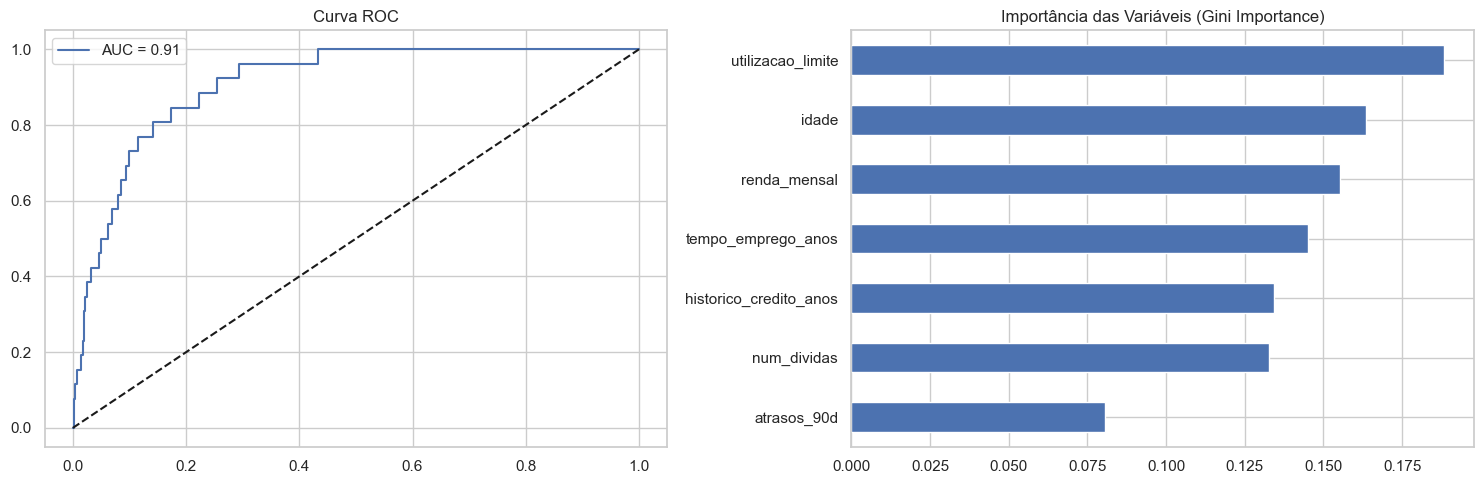

In [37]:
#Célula 6: Visualização de Resultados e Importância das Variáveis
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Curva ROC
ax[0].plot(fpr, tpr, label=f'AUC = {auc:.2f}')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('Curva ROC')
ax[0].legend()

# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', ax=ax[1])
ax[1].set_title('Importância das Variáveis (Gini Importance)')
plt.tight_layout()
plt.show()

In [38]:
#Célula 7: Função de Scoring (Simulação de Produção)

def credit_scoring_engine(data_dict):
    """Converte dados brutos em Score e Rating."""
    df_input = pd.DataFrame([data_dict])
    df_scaled = scaler.transform(df_input)
    prob = model.predict_proba(df_scaled)[0, 1]
    
    # Mapeamento para Score 300-850
    score = int(round((1 - prob) * 550 + 300))
    
    # Definição de Rating
    if score >= 750: rating = 'AAA'
    elif score >= 650: rating = 'AA'
    elif score >= 500: rating = 'A'
    elif score >= 400: rating = 'B'
    else: rating = 'C (Alto Risco)'
    
    return {
        "Score": score,
        "Rating": rating,
        "PD (Prob. Default)": f"{prob:.2%}"
    }

# Teste prático
perfil_teste = {
    'idade': 42, 'renda_mensal': 12000.0, 'tempo_emprego_anos': 10.0,
    'utilizacao_limite': 0.12, 'atrasos_90d': 0, 'num_dividas': 2,
    'historico_credito_anos': 15.0
}

print("Resultado do Scoring:")
print(credit_scoring_engine(perfil_teste))



Resultado do Scoring:
{'Score': 850, 'Rating': 'AAA', 'PD (Prob. Default)': '0.00%'}
